# Evaluation of Batch Correction using Flow-based Density Ratio Estimators.


## Prepare the notebook.

### Autoreload notebook.

In [19]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Import the libraries.

In [1]:
import os
import random

import lightning as L
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import scvi
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
import torch
from torchdyn.core import NeuralODE
from tqdm.auto import tqdm 

from utils import ConditionalFlowMatchingWithScore
from scFM_density_estimation.models import NODEWrapper

torch.set_float32_matmul_precision('medium')

### Constants and Paths.

In [3]:
DATA_DIR = "/lustre/groups/ml01/workspace/alessandro.palma/celldreamer/datasets/processed_full_genome/neurips"
FULL_H5AD_PATH = os.path.join(DATA_DIR, "neurips.h5ad")
TRAIN_H5AD_PATH = os.path.join(DATA_DIR, "neurips_train.h5ad")
TEST_H5AD_PATH = os.path.join(DATA_DIR, "neurips_test.h5ad")

LAYERS_KEY = "X_counts"
BATCH_KEY = "batch"
LABELS_KEY = "cell_type"

USE_HVG_ONLY = True
USE_SYSVI = True

N_DIMS = 50
RANDOM_SEED = 1024

### Set reproducibility.

In [4]:
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = True
torch.manual_seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

### Utility functions.

In [5]:
def div_fn_hutch_trace(u):
    def div_fn(x, eps):
        _, vjpfunc = torch.func.vjp(u, x)
        return (vjpfunc(eps)[0] * eps).sum()

    return div_fn

class NODEWrapper_with_ratio_tvf_rl(torch.nn.Module):
    def __init__(self, model, C):
        super().__init__()
        self.model = model
        self.C = C
        self.div_fn, self.eps_fn = div_fn_hutch_trace, torch.randn_like

    def forward(self, t, x, **kwargs):
        x = x[..., :-1]
        
        def vecfield(y):
            ut, _ = self.model(y.unsqueeze(0), t, self.C, [True, True])
            vt, _ = self.model(y.unsqueeze(0), t, self.C, [True, False])
            return vt.squeeze() - ut.squeeze()
            
        div = torch.vmap(self.div_fn(vecfield))(x, self.eps_fn(x))
        
        ut = self.model(x, t, self.C, [True, True],  return_score=False)
        vt, score_v = self.model(x, t, self.C, [True, False], return_score=True)

        correction_term_u = torch.linalg.vecdot(ut - vt, score_v)
        dr = div + correction_term_u
        
        return torch.cat([ut, dr[:, None]], dim=-1)

## Read Data.

### Load `.h5ad` files into memory.

In [6]:
adata_full = sc.read_h5ad(FULL_H5AD_PATH)
adata_train = sc.read_h5ad(TRAIN_H5AD_PATH)
adata_test = sc.read_h5ad(TEST_H5AD_PATH)
print(f"{adata_full=}\n{adata_train=}\n{adata_test=}")

/home/icb/lorenzo.consoli/miniconda3/envs/sc_flow_density/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/icb/lorenzo.consoli/miniconda3/envs/sc_flow_density/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


adata_full=AnnData object with n_obs × n_vars = 90261 × 14087
    obs: 'GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train'
    var: 'feature_types', 'gene_id', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cell_type_colors', 'dataset_id', 'genome', 'hvg', 'log1p', 'neighbors', 'organism', 'pca', 'umap'
    obsm: 'ADT_X_pca', 'ADT_X_umap', 'ADT_isotype_controls', 'GEX_X_pca', 'GEX_X_umap', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'X_counts'
    obsp: 'connectivities', 'distances'
adata_train=AnnData object with n_obs × n_vars = 72208 × 14087
    obs: 'GEX_n_genes_by_counts', '

/home/icb/lorenzo.consoli/miniconda3/envs/sc_flow_density/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


### Visualize cell states.

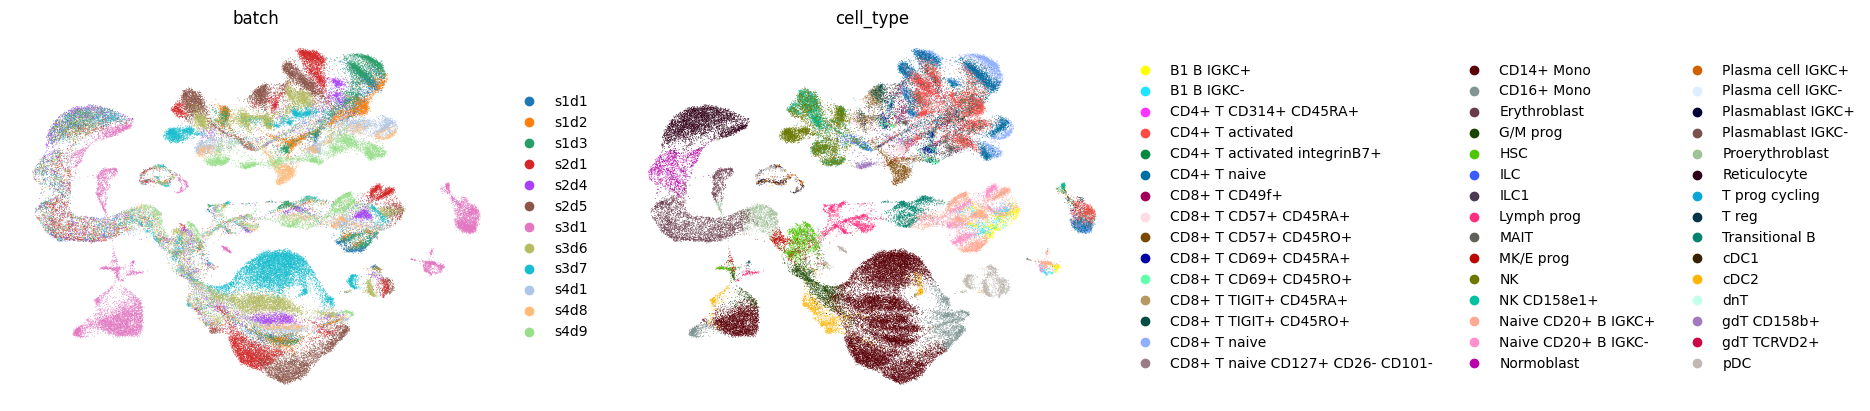

In [7]:
sc.pl.embedding(adata_full, "umap", color=["batch", "cell_type"], frameon=False)

### Inspect batch labels.

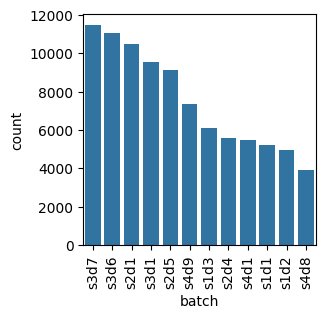

In [8]:
order = adata_full.obs["batch"].value_counts().index
plt.figure(figsize=(3, 3))
sns.countplot(data=adata_full.obs, x="batch", order=order)
plt.tick_params("x", rotation=90)

### Inspect cell type labels.

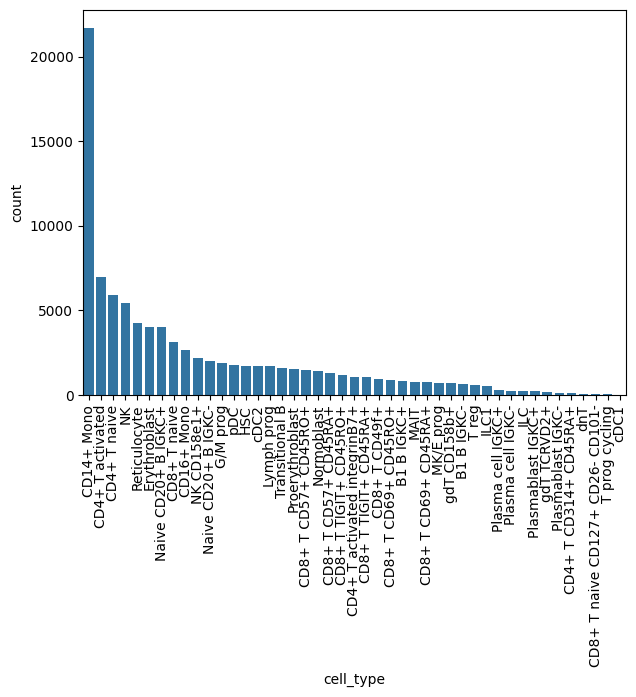

In [9]:
order = adata_full.obs["cell_type"].value_counts().index
plt.figure(figsize=(7, 5))
sns.countplot(data=adata_full.obs, x="cell_type", order=order)
plt.tick_params("x", rotation=90)

### Select Highly Variable Genes.

In [10]:
if USE_HVG_ONLY:
    adata_full = adata_full[:, adata_full.var["highly_variable"]]

### Convert data to sparse.

In [11]:
if LAYERS_KEY is not None:
    if sp.issparse(adata_full.layers[LAYERS_KEY]):
        adata_full.layers[LAYERS_KEY] = adata_full.layers[LAYERS_KEY].tocsr()

/tmp/ipykernel_2524425/502236238.py:3: ImplicitModificationWarning: Setting element `.layers['X_counts']` of view, initializing view as actual.
  adata_full.layers[LAYERS_KEY] = adata_full.layers[LAYERS_KEY].tocsr()
/home/icb/lorenzo.consoli/miniconda3/envs/sc_flow_density/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


### Plots variance ratio.

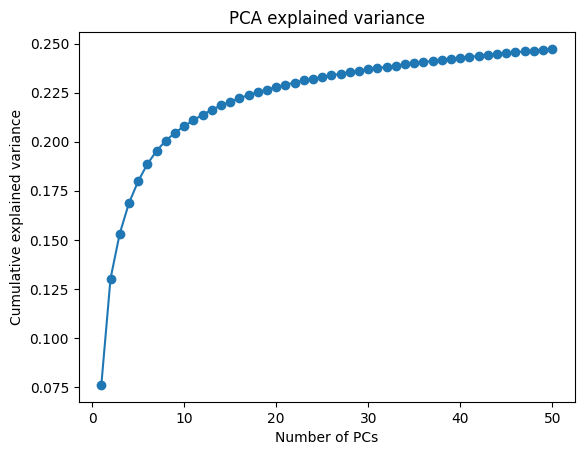

In [12]:
var = adata_full.uns["pca"]["variance_ratio"]
cum_var = np.cumsum(var)

plt.figure()
plt.plot(range(1, len(var)+1), cum_var, marker="o")
plt.xlabel("Number of PCs")
plt.ylabel("Cumulative explained variance")
plt.title("PCA explained variance")
plt.show()


## Fit SCVI.


### Train Model.

In [13]:
scvi.model.SCVI.setup_anndata(
    adata_full,
    layer=LAYERS_KEY,
    batch_key=BATCH_KEY,
    labels_key=LABELS_KEY
)
model = scvi.model.SCVI(
    adata_full,
    n_latent=N_DIMS,
)
plan_kwargs={
    "optimizer": "AdamW",
    "kl_weight": 0.1,
    "lr": 5e-4,
    "n_epochs_kl_warmup": 50
}
model.train(
    # max_epochs=20,
    plan_kwargs=plan_kwargs,
    validation_size=0.3,
    train_size=0.7,
    check_val_every_n_epoch=1,
)

/home/icb/lorenzo.consoli/miniconda3/envs/sc_flow_density/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/icb/lorenzo.consoli/miniconda3/envs/sc_flow_de ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/icb/lorenzo.consoli/miniconda3/envs/sc_flow_density/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/icb/lorenzo.consoli/miniconda3/envs/sc_flow_de ...
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/icb/lorenzo.consoli/miniconda3/envs/sc_flow_density/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data

Training:   0%|          | 0/89 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=89` reached.


### Plot training dynamics.

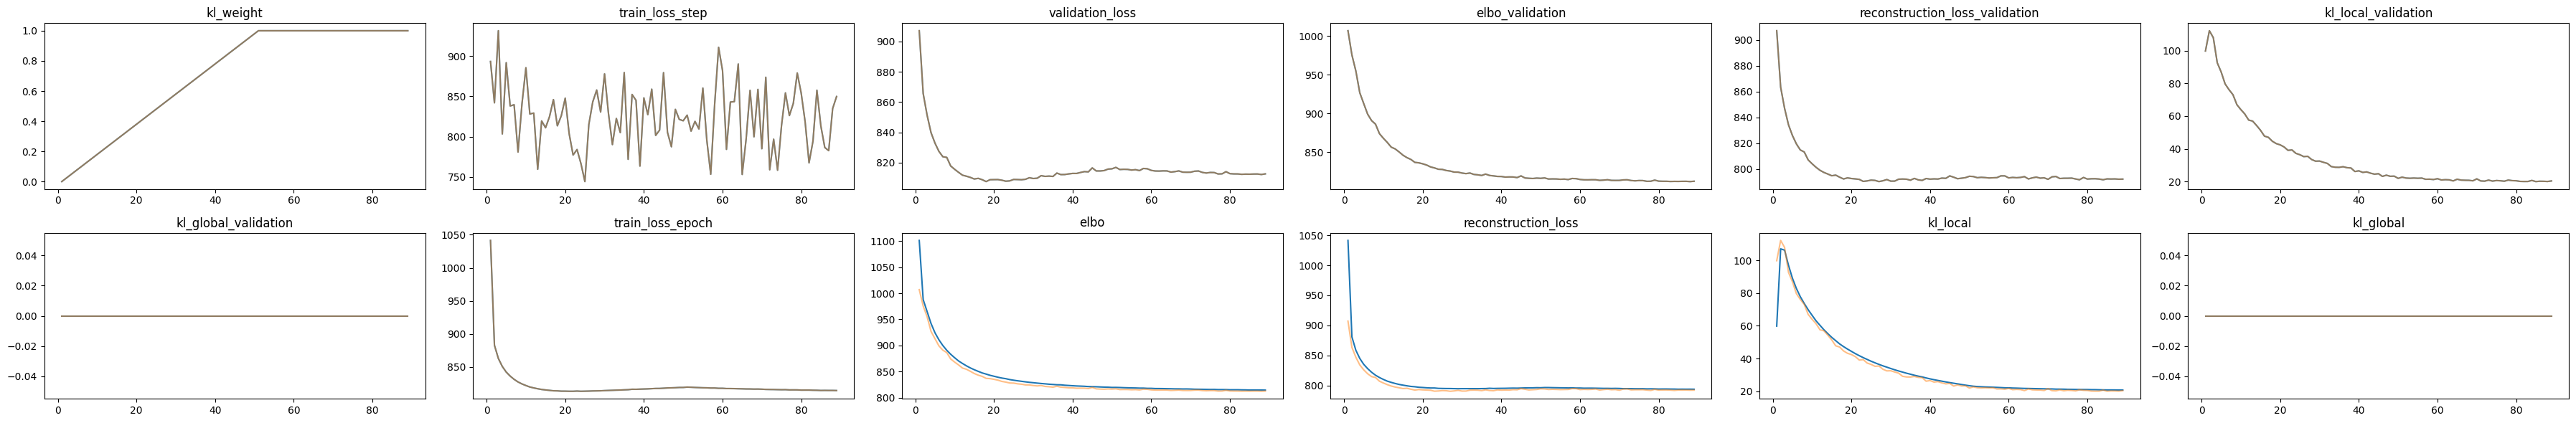

In [14]:
# Make detailed plot after N epochs
epochs_detail_plot = 100

# Losses to plot
losses = list(model.trainer.logger.history.keys())
fig, axs = plt.subplots(2, len(losses)//2, figsize=(len(losses) * 3, 6))
axs = axs.flatten()
for ax_i, l_train in enumerate(losses):
    l_val = l_train.replace("_train", "_validation")
    l_name = l_train.replace("_train", "")
    # Change idx of epochs to start with 1
    l_val_values = model.trainer.logger.history[l_val].copy()
    l_val_values.index = l_val_values.index + 1
    l_train_values = model.trainer.logger.history[l_train].copy()
    l_train_values.index = l_train_values.index + 1
    for l_values, c, alpha, dp in [
        (l_train_values, "tab:blue", 1, epochs_detail_plot),
        (l_val_values, "tab:orange", 0.5, epochs_detail_plot),
    ]:
        axs[ax_i].plot(l_values.index, l_values.values.ravel(), c=c, alpha=alpha)
        axs[ax_i].set_title(l_name)
        # axs[1, ax_i].plot(l_values.index[dp:], l_values.values.ravel()[dp:], c=c, alpha=alpha)

fig.tight_layout()

### Visualize embeddings.

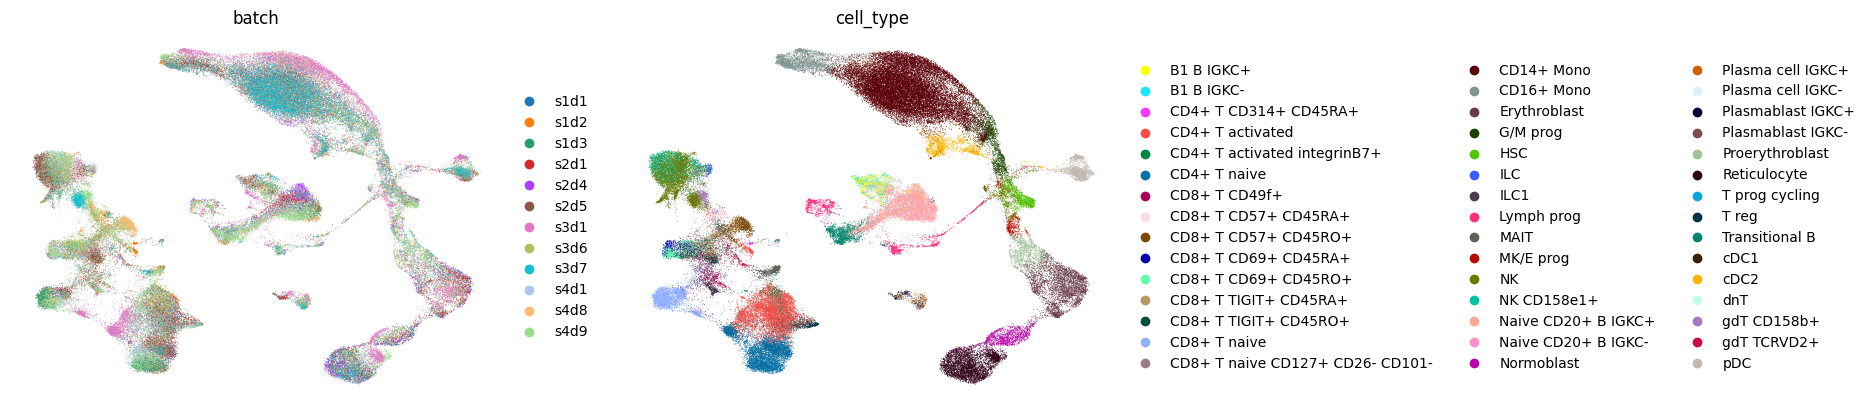

In [15]:
NEIGHBORS_KEY = "scVI_neighbors"
UMAP_KEY = "X_umap_scVI"
SCVI_LATENT_KEY = "X_scVI"

adata_full.obsm[SCVI_LATENT_KEY] = model.get_latent_representation()
sc.pp.neighbors(adata_full, use_rep=SCVI_LATENT_KEY, key_added=NEIGHBORS_KEY)
sc.tl.umap(adata_full, neighbors_key=NEIGHBORS_KEY, key_added=UMAP_KEY, min_dist=0.3)
sc.pl.embedding(adata_full, UMAP_KEY, color=["batch", "cell_type"], frameon=False)


## Fit flow model on uncorrected data.

### Prepare Flow Model.

In [16]:
sigma = 0.0
sigma_min = 1e-2
lambda_t = lambda t: torch.sqrt((1 - (1 - sigma_min) * t) ** 2 + sigma * t * (1 - t))
lambda_sp_t = lambda t: (sigma * (1 - 2 * t) - 2 * (1 - sigma_min) * (1 - (1 - sigma_min) * t)) / 2

model = ConditionalFlowMatchingWithScore(
    input_dim=N_DIMS,
    cond_dims=[adata_train.obs["cell_type"].nunique(), adata_train.obs["batch"].nunique()],
    hidden_dims=[1024, 1024, 1024],
    encoder_hidden_dims=[256],
    encoder_out_dim=50,
    lambda_t=lambda_t,
    lambda_sp_t=lambda_sp_t,
    betas=[0.2, 0.2],
    lr=1e-4
).to("cuda")
optimizer = model.configure_optimizers()

### Train Model.

In [17]:
X_train = torch.from_numpy(adata_full.obsm["X_pca"]).float().cuda()
C_train = np.concatenate(
    (
        OneHotEncoder().fit_transform(adata_full.obs[["cell_type"]]).toarray(),
        OneHotEncoder().fit_transform(adata_full.obs[["batch"]]).toarray(),
    ), axis=1
)
C_train = torch.from_numpy(C_train).float().cuda()

n_steps = 100_000
batch_size = 1024

loss_history = []
pbar = tqdm(range(n_steps))
ema_loss = None

for k in pbar:
    optimizer.zero_grad()

    indices = np.random.choice(range(X_train.shape[0]), size=batch_size, replace=False)
    loss = model.shared_step(X_train[indices], C_train[indices])
    
    loss.backward()
    optimizer.step()

    if ema_loss is None:
        ema_loss = loss.item()
    else:
        ema_loss = alpha * ema_loss + (1 - alpha) * loss.item() 
    loss_history.append(ema_loss)

    if (k + 1) % 100 == 0:
        pbar.set_description(f"Step {k+1}, EMA Loss: {ema_loss:.3f}")
        pbar.update()

  0%|          | 0/100000 [00:00<?, ?it/s]

### Get unique conditions.

In [18]:
unique_conds = torch.unique(C_train, dim=0)
unique_conds.shape


torch.Size([431, 57])

### Sample and compute density ratio.

In [19]:
n_samples = 10_000
usamples_dict = {}
ulikelihood_ratios_dict = {}

for idx in tqdm(range(unique_conds.shape[0])):
    # push forward noise
    C = unique_conds[idx].unsqueeze(0).repeat(n_samples, 1)
    node = NeuralODE(
        NODEWrapper(model=model, cond=C, use_conds=[True, True], return_score=False),
        solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4
    )
    with torch.no_grad():
        traj = node.trajectory(
            torch.randn((n_samples, X_train.shape[1])).float().cuda(),
            t_span=torch.linspace(0, 1, 100).to("cuda")
        )
    samples = traj[-1]
    usamples_dict[idx] = samples.detach().cpu().numpy()

    # compute density ratio
    C_mask_train = torch.all(C_train == unique_conds[idx], axis=1)
    x =  X_train[C_mask_train]
    c = unique_conds[idx].unsqueeze(0)
    node_llr = NeuralODE(
        NODEWrapper_with_ratio_tvf_rl(model, c),
        solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4
    )
    with torch.no_grad():
        traj = node_llr.trajectory(
            torch.cat([x, torch.zeros(x.shape[0], 1).to("cuda")], dim=-1),
            t_span=torch.linspace(1, 0, 100).to("cuda")
        )
    ulikelihood_ratios_dict[idx] = traj[-1].detach().cpu().numpy()
    break

  0%|          | 0/431 [00:00<?, ?it/s]

### Decode Samples with PCA.

In [20]:
decode_samples = False
udecoded_samples = {}
for idx, samples in tqdm(usamples_dict.items()):
    if decode_samples:
        dec_samples = torch.einsum("nk,dk->nd", torch.from_numpy(samples[:, :-1]).float().cuda(),
            torch.from_numpy(adata_full.varm["PCs"]).float().cuda()) + torch.from_numpy(adata_full.var.means.values).float().cuda()
        udecoded_samples[idx] = dec_samples.detach().cpu().numpy()
    else:
        udecoded_samples[idx] = samples
    break

  0%|          | 0/1 [00:00<?, ?it/s]

### Visualize generated samples.

In [21]:
uadata_pred_dict = {}
X_train = adata_full.X.toarray() if decode_samples else adata_full.obsm["X_pca"]
for idx, dec_samples in udecoded_samples.items():
    C = unique_conds[idx].cpu().numpy()
    C_mask_train = np.all(C_train.detach().cpu().numpy() == C, axis=1)
    C_mask_gen = np.full((n_samples, ), fill_value=True)
    C_mask = np.concatenate((C_mask_train, C_mask_gen), axis=0)
    X = np.concat(
        (X_train, dec_samples), axis=0
    )
    adata_gen = sc.AnnData(
        X=X,
        obs={"is_target_c": C_mask, "is_gen": np.concatenate((np.full((X_train.shape[0], ), fill_value=False), np.full((n_samples, ), fill_value=True)), axis=0)},
    )
    if decode_samples:
        sc.pp.pca(adata_gen)
    sc.pp.neighbors(adata_gen)
    sc.tl.umap(adata_gen)
    uadata_pred_dict[idx] = adata_gen
    break


### Visualize samples.

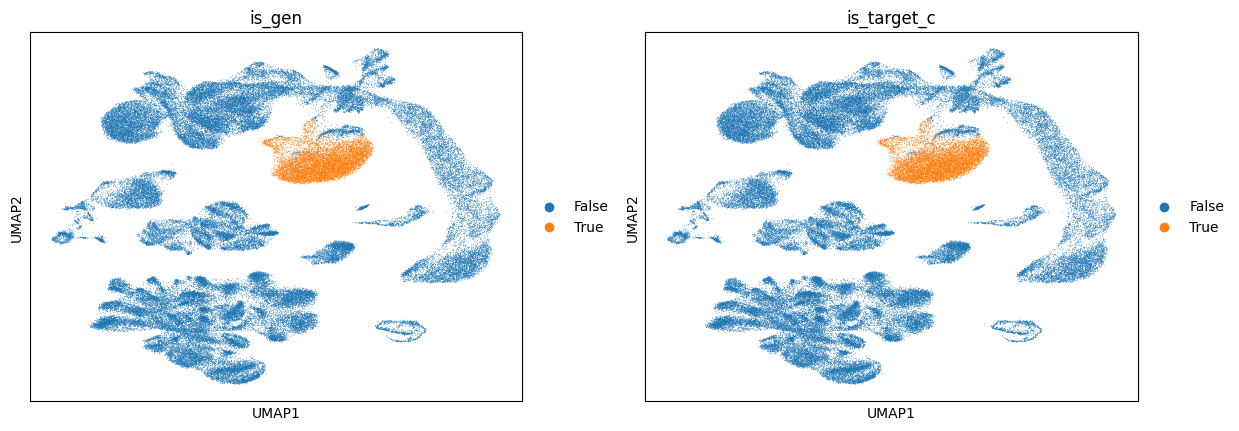

In [22]:
for idx, adata_gen in uadata_pred_dict.items():
    sc.pl.embedding(adata_gen, "umap", color=["is_gen", "is_target_c"])

### Visualize distribution of density ratios.

0 (32, 50) (32,)


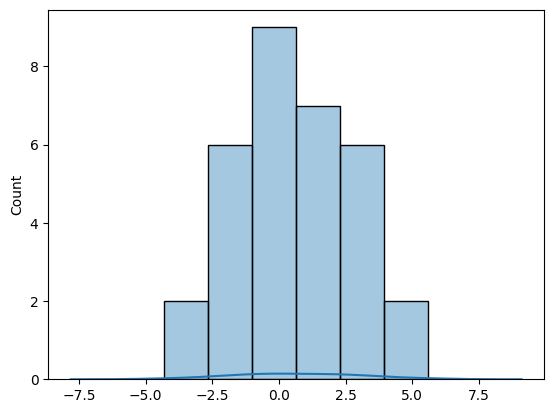

In [23]:
for cond_id, cond_pb_density in ulikelihood_ratios_dict.items():
    noise, llr = cond_pb_density[:, :-1], cond_pb_density[:, -1]
    sns.histplot(llr, alpha=0.4)
    sns.kdeplot(llr)
    print(cond_id, noise.shape, llr.shape)

## Fit Flow Model on Corrected Representations.

### Prepare model.

In [24]:
sigma = 0.0
sigma_min = 1e-2
lambda_t = lambda t: torch.sqrt((1 - (1 - sigma_min) * t) ** 2 + sigma * t * (1 - t))
lambda_sp_t = lambda t: (sigma * (1 - 2 * t) - 2 * (1 - sigma_min) * (1 - (1 - sigma_min) * t)) / 2

model_corr = ConditionalFlowMatchingWithScore(
    input_dim=N_DIMS,
    cond_dims=[adata_train.obs["cell_type"].nunique(), adata_train.obs["batch"].nunique()],
    hidden_dims=[1024, 1024, 1024],
    encoder_hidden_dims=[256],
    encoder_out_dim=50,
    lambda_t=lambda_t,
    lambda_sp_t=lambda_sp_t,
    betas=[0.2, 0.2],
    lr=1e-4
).to("cuda")
optimizer = model_corr.configure_optimizers()

### Train Model.

In [25]:
X_train = torch.from_numpy(adata_full.obsm[SCVI_LATENT_KEY]).float().cuda()
C_train = np.concatenate(
    (
        OneHotEncoder().fit_transform(adata_full.obs[["cell_type"]]).toarray(),
        OneHotEncoder().fit_transform(adata_full.obs[["batch"]]).toarray(),
    ), axis=1
)
C_train = torch.from_numpy(C_train).float().cuda()

n_steps = 100_000
batch_size = 1024

loss_history = []
pbar = tqdm(range(n_steps))
ema_loss = None

for k in pbar:
    optimizer.zero_grad()

    indices = np.random.choice(range(X_train.shape[0]), size=batch_size, replace=False)
    loss = model_corr.shared_step(X_train[indices], C_train[indices])
    
    loss.backward()
    optimizer.step()

    if ema_loss is None:
        ema_loss = loss.item()
    else:
        ema_loss = alpha * ema_loss + (1 - alpha) * loss.item() 
    loss_history.append(ema_loss)

    if (k + 1) % 100 == 0:
        pbar.set_description(f"Step {k+1}, EMA Loss: {ema_loss:.3f}")
        pbar.update()

  0%|          | 0/100000 [00:00<?, ?it/s]

### Compute density ratios.

In [26]:
n_samples = 10_000
csamples_dict = {}
clikelihood_ratios_dict = {}

for idx in tqdm(range(unique_conds.shape[0])):
    # push forward noise
    C = unique_conds[idx].unsqueeze(0).repeat(n_samples, 1)
    node = NeuralODE(
        NODEWrapper(model=model_corr, cond=C, use_conds=[True, True], return_score=False),
        solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4
    )
    with torch.no_grad():
        traj = node.trajectory(
            torch.randn((n_samples, X_train.shape[1])).float().cuda(),
            t_span=torch.linspace(0, 1, 100).to("cuda")
        )
    samples = traj[-1]
    csamples_dict[idx] = samples.detach().cpu().numpy()

    # compute density ratio
    C_mask_train = torch.all(C_train == unique_conds[idx], axis=1)
    x =  X_train[C_mask_train]
    c = unique_conds[idx].unsqueeze(0)
    node_llr = NeuralODE(
        NODEWrapper_with_ratio_tvf_rl(model_corr, c),
        solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4
    )
    with torch.no_grad():
        traj = node_llr.trajectory(
            torch.cat([x, torch.zeros(x.shape[0], 1).to("cuda")], dim=-1),
            t_span=torch.linspace(1, 0, 100).to("cuda")
        )
    clikelihood_ratios_dict[idx] = traj[-1].detach().cpu().numpy()
    break

  0%|          | 0/431 [00:00<?, ?it/s]

### VIsualize samples.

In [27]:
cadata_pred_dict = {}
X_train = adata_full.obsm[SCVI_LATENT_KEY]
for idx, dec_samples in csamples_dict.items():
    C = unique_conds[idx].cpu().numpy()
    C_mask_train = np.all(C_train.detach().cpu().numpy() == C, axis=1)
    C_mask_gen = np.full((n_samples, ), fill_value=True)
    C_mask = np.concatenate((C_mask_train, C_mask_gen), axis=0)
    X = np.concat(
        (X_train, dec_samples), axis=0
    )
    adata_gen = sc.AnnData(
        X=X,
        obs={"is_target_c": C_mask, "is_gen": np.concatenate((np.full((X_train.shape[0], ), fill_value=False), np.full((n_samples, ), fill_value=True)), axis=0)},
    )
    # sc.pp.pca(adata_gen)
    sc.pp.neighbors(adata_gen)
    sc.tl.umap(adata_gen)
    cadata_pred_dict[idx] = adata_gen
    break


### Visualize predictions.

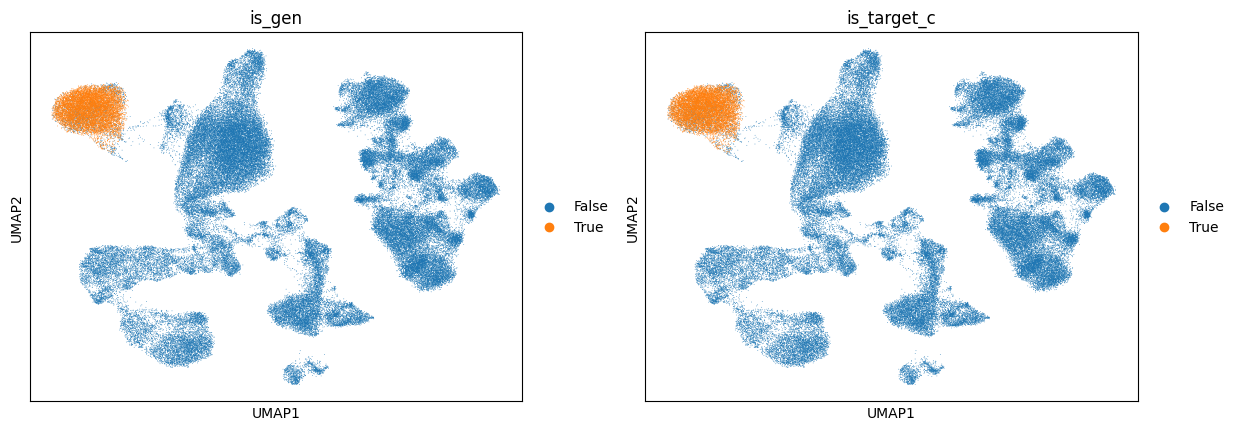

In [28]:
for idx, adata_gen in cadata_pred_dict.items():
    sc.pl.embedding(adata_gen, "umap", color=["is_gen", "is_target_c"])

### Utility function to automatically get cell type and batch names.

In [29]:
def get_ct_and_batch(
    adata_full,
    cond_id,
    unique_conds,
):
    ohe_ct = OneHotEncoder().fit(adata_full.obs[["cell_type"]])
    ohe_batch = OneHotEncoder().fit(adata_full.obs[["batch"]])
    cond_dims = [adata_train.obs["cell_type"].nunique(), adata_train.obs["batch"].nunique()]
    ct_vec = ohe_ct.inverse_transform(unique_conds[cond_id][:cond_dims[0]][None].detach().cpu().numpy())
    batch_vec = ohe_batch.inverse_transform(unique_conds[cond_id][cond_dims[0]:][None].detach().cpu().numpy())
    return ct_vec[0][0], batch_vec[0][0]

### Plot density ratios.

0 (32, 50) (32,)


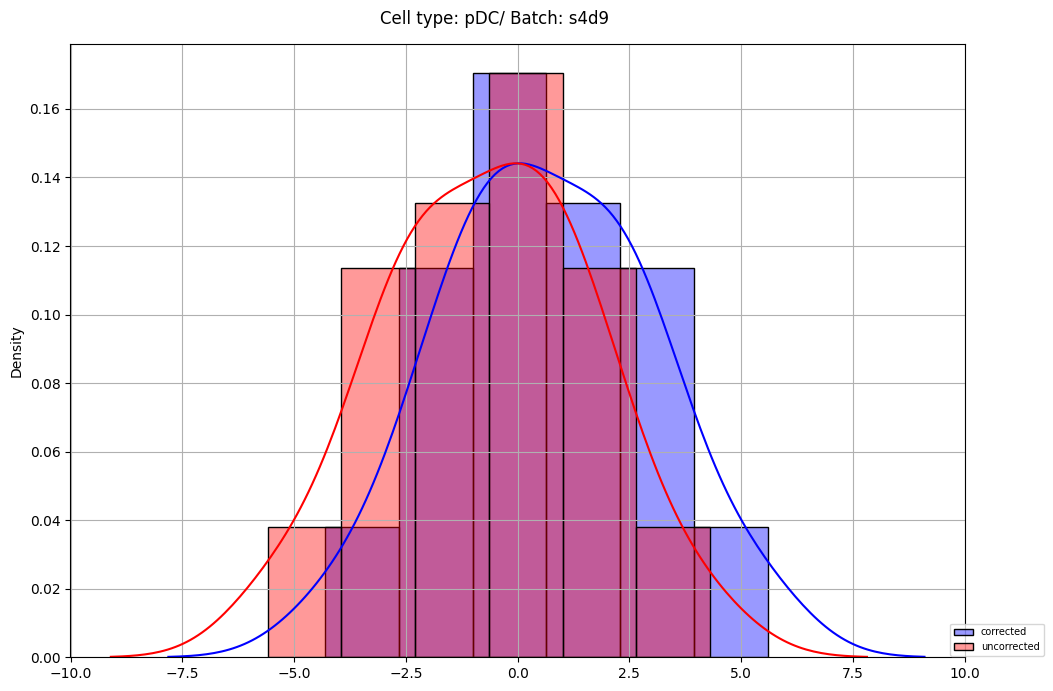

In [30]:
for cond_id, cond_pb_density in clikelihood_ratios_dict.items():
    ct_name, batch_name = get_ct_and_batch(adata_full, cond_id, unique_conds)
    cnoise, cllr = cond_pb_density[:, :-1], -cond_pb_density[:, -1]
    ucond_pb_density = ulikelihood_ratios_dict[cond_id]
    unoise, ullr = ucond_pb_density[:, :-1], -ucond_pb_density[:, -1]
    fig, ax = plt.subplots(figsize=(10, 7), dpi=100)
    fig.suptitle(f"Cell type: {ct_name}/ Batch: {batch_name}", size=12)
    sns.histplot(llr, alpha=0.4, color="blue", label="corrected", stat="density", ax=ax)
    sns.kdeplot(llr, color="blue", ax=ax)
    sns.histplot(ullr, alpha=0.4, color="red", label="uncorrected", stat="density", ax=ax)
    sns.kdeplot(ullr, color="red", ax=ax)
    ax.grid(True)
    fig.legend(
        loc="lower left",
        bbox_to_anchor=(0.95, 0.05),
        fontsize=7,
        markerscale=0.8 
    )
    fig.tight_layout()

    print(cond_id, noise.shape, llr.shape)

In [31]:
adata_full

AnnData object with n_obs × n_vars = 90261 × 2014
    obs: 'GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train', '_scvi_batch', '_scvi_labels'
    var: 'feature_types', 'gene_id', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cell_type_colors', 'dataset_id', 'genome', 'hvg', 'log1p', 'neighbors', 'organism', 'pca', 'umap', 'batch_colors', '_scvi_uuid', '_scvi_manager_uuid', 'scVI_neighbors', 'X_umap_scVI'
    obsm: 'ADT_X_pca', 'ADT_X_umap', 'ADT_isotype_controls', 'GEX_X_pca', 'GEX_X_umap', 'X_pca', 'X_umap', 'X_scVI', 'X_umap_scVI'
    varm: 'PCs'
    layers: 'X_counts'
    obsp:

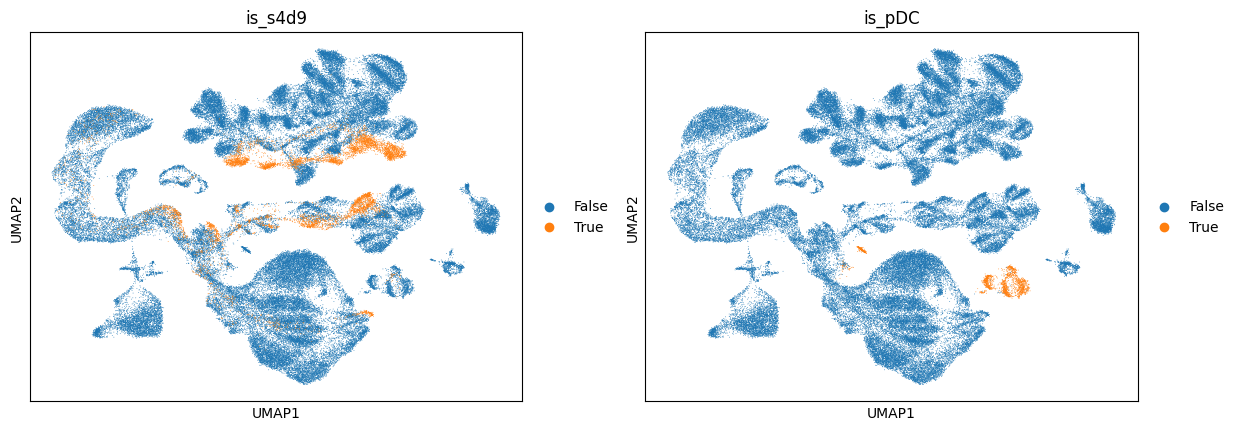

In [33]:
ct = "pDC"; is_ct_string = f"is_{ct}"
batch = "s4d9"; is_batch_string = f"is_{batch}"
adata_full.obs[is_ct_string] = adata_full.obs["cell_type"] == ct
adata_full.obs[is_batch_string] = adata_full.obs["batch"] == batch
sc.pl.embedding(adata_full, "umap", color=[is_batch_string, is_ct_string])

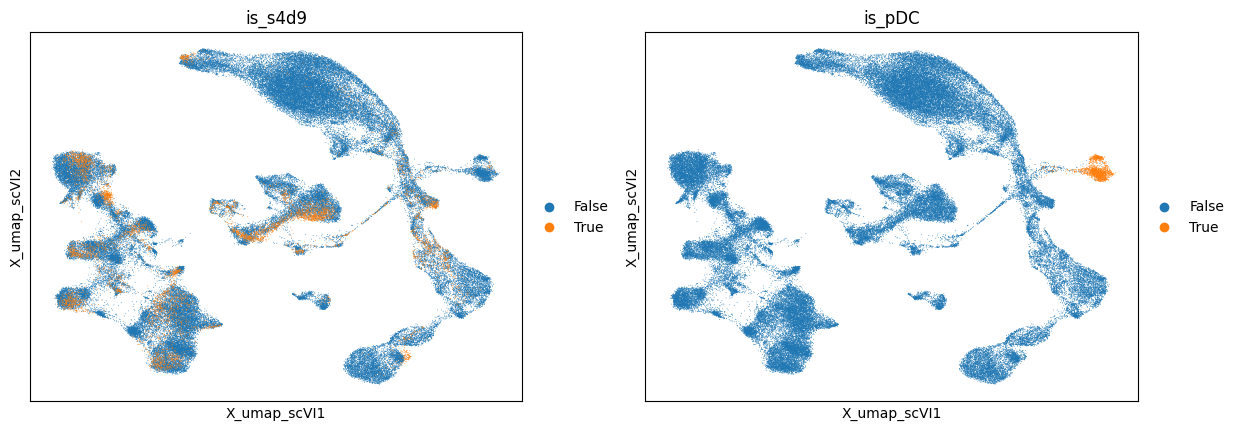

In [32]:
ct = "pDC"; is_ct_string = f"is_{ct}"
batch = "s4d9"; is_batch_string = f"is_{batch}"
adata_full.obs[is_ct_string] = adata_full.obs["cell_type"] == ct
adata_full.obs[is_batch_string] = adata_full.obs["batch"] == batch
sc.pl.embedding(adata_full, "X_umap_scVI", color=[is_batch_string, is_ct_string])

### 